# Plots
Generate plots for the paper.

In [74]:
# this part below is common to all plots
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

# let's also set some colors for the different regressors, to be used in the plots
regressor_colors = {
    "PySRRegressor": "orange",
    "RandomForestRegressor": "lightgreen",
    "XGBRegressor": "cornflowerblue",
}

plots_folder = "../plots"
if not os.path.exists(plots_folder) :
    os.makedirs(plots_folder)

## Histogram bar timing all algorithms
This is a series of histograms with the timing, sorting the datasets by either number of samples or matrix size.

Regressor names: ['PySRRegressor', 'RandomForestRegressor', 'XGBRegressor']
Time columns: ['time_PySRRegressor_default', 'time_RandomForestRegressor', 'time_XGBRegressor']
[71040.0, 70830.0, 70990.0, 73190.0, 71850.0, 71650.0, 71260.0, 71520.0, 71210.0, 72350.0, 72040.0, 72360.0, 71210.0, 73580.0, 73590.0, 72340.0, 77810.0]
[4.851502952770544, 4.850217241798389, 4.851197176174161, 4.864451747158183, 4.856426772470244, 4.855216194733363, 4.8528458180149965, 4.854427505787862, 4.8525409857697985, 4.859438535455056, 4.857573704147495, 4.859498558187776, 4.8525409857697985, 4.866759783495108, 4.866818802926048, 4.859378504425601, 4.891035415315311]
[160.0, 160.0, 160.0, 140.0, 170.0, 160.0, 160.0, 140.0, 160.0, 160.0, 170.0, 200.0, 140.0, 210.0, 210.0, 190.0, 210.0]
[2.2041199826559246, 2.2041199826559246, 2.2041199826559246, 2.146128035678238, 2.230448921378274, 2.2041199826559246, 2.2041199826559246, 2.146128035678238, 2.2041199826559246, 2.2041199826559246, 2.230448921378274, 2.30102999

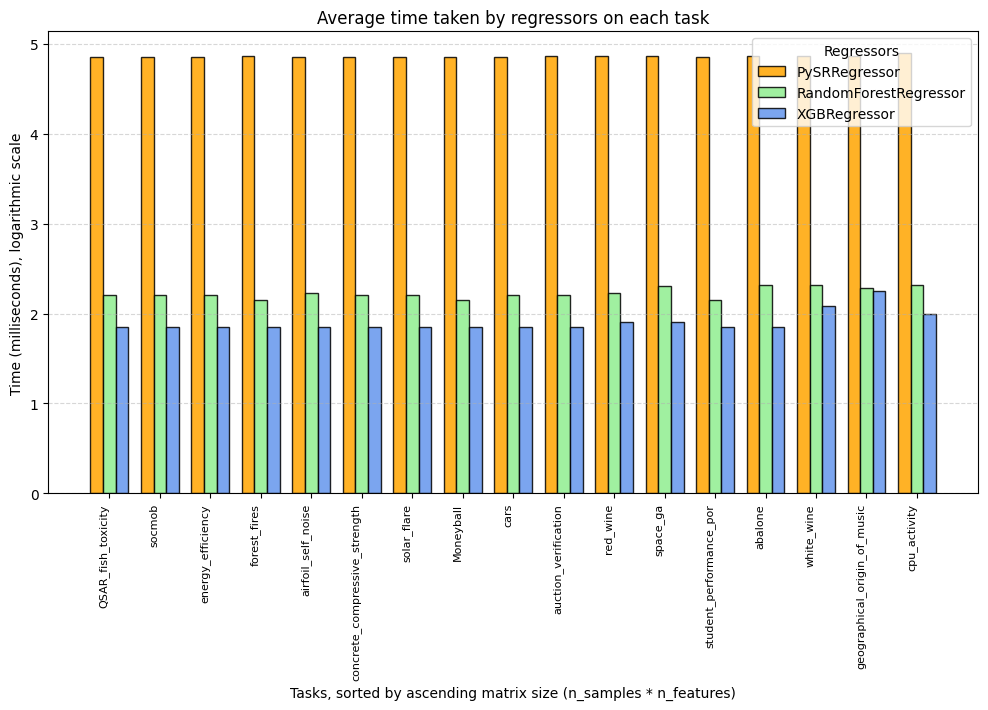

In [ ]:
# hard-coded values
results_file = "../results_20260519_only_tree_models/analysis_openml_ctr23_statistics.csv"
results_file = "../results_server_20260519/analysis_openml_ctr23_statistics.csv"
plot_filename = os.path.join(plots_folder, "time_comparison_default.png")

# read the results file
df = pd.read_csv(results_file, thousands=",") # to correctly parse numbers with commas as thousands separators

# sort the rows by matrix size (number of samples * number of features), to have a more meaningful order in the plots
df["matrix_size"] = df["n_samples"] * df["n_features"]
df = df.sort_values(by="matrix_size", ascending=True).reset_index(drop=True)

tasks = df["task_id"].values
task_names = df["dataset_name"].values
num_tasks = tasks.shape[0]
time_columns = [c for c in df.columns if c.startswith("time") and c.find("PySRRegressor") == -1]
time_columns_pysr = [c for c in df.columns if c.find("time_PySRRegressor") != -1]
if len(time_columns_pysr) > 0 :
     time_columns.append(time_columns_pysr[0])

# this is just a special case for "PySRRegressor", because the columns related
# to this regressor appear in duplicates (default and validation), so we will rename them to be more explicit
regressor_names = []
for c in time_columns :
    if c.startswith("time_PySRRegressor") and "PySRRegressor" not in regressor_names :
        regressor_names.append("PySRRegressor")
    else :
        regressor_names.append(c.split("_")[1])
num_regressors = len(regressor_names)

# sort in alphabetical order
regressor_names = sorted(regressor_names)
time_columns = sorted(time_columns)

print("Regressor names:", regressor_names)
print("Time columns:", time_columns)

# set the coordinates of the bars for the time plot
x = np.arange(num_tasks)
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, time_column in enumerate(time_columns):
        # Calculate the offset for this specific regressor's bar group
        offset = (i - (num_regressors - 1) / 2) * width
        times = [float(v.split(" ")[0]) * 1000 for v in df[time_column].values] # convert seconds to milliseconds
        log_times = [math.log10(t) for t in times]
        regressor_name = regressor_names[i]

        print(times)
        print(log_times)

        bars = ax.bar(
            x + offset,
            log_times,
            width,
            label=regressor_name,
            color=regressor_colors.get(regressor_name, "gray"),
            edgecolor="black",
            alpha=0.85,
        )

        # Add value labels on top of each bar
        #for bar in bars:
        #    height = bar.get_height()
        #    ax.annotate(
        #        f"{height:.2f}s",
        #        xy=(bar.get_x() + bar.get_width() / 2, height),
        #        xytext=(0, 3),  # 3 points vertical offset
        #        textcoords="offset points",
        #        ha="center",
        #        va="bottom",
        #        fontsize=8,
        #    )

# aesthetics
ax.set_title("Average time taken by regressors on each task") #, fontsize=14, pad=15)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_ylabel("Time (milliseconds), logarithmic scale")
ax.set_xlabel("Tasks, sorted by ascending matrix size (n_samples * n_features)")
ax.set_xticks(x)
ax.set_xticklabels(task_names, rotation=90, ha="right", fontsize=8)
ax.legend(title="Regressors")
#plt.tight_layout()

# save the plot
plt.savefig(plot_filename, dpi=150, bbox_inches="tight")
